In [1]:
import Pkg

Pkg.activate(normpath(joinpath(@__DIR__, "..")))

using LongitudinalTomography

  Activating project at `~/Desktop/longitudinal_dynamics`


In [2]:
# Import packages
using LongitudinalTomography
using CairoMakie
using Printf

# Define the global theme for regular text and mathematical equations
set_theme!(Theme(
    font = "StixGeneral",
    mathfont = "StixGeneral",
    
    # Force individual elements to inherit it correctly
    titlefont = "StixGeneral",
    xlabelfont = "StixGeneral",
    ylabelfont = "StixGeneral",
    xticklabelfont = "StixGeneral",
    yticklabelfont = "StixGeneral"
))


# CairoMakie.activate!()


In [3]:
# Create machine to simulate
const PROTON_MASS_EV = 938.2720813e6

kinetic_energy_eV = 8.0e9
total_energy_eV = kinetic_energy_eV + PROTON_MASS_EV
gamma_s = total_energy_eV / PROTON_MASS_EV
beta_s = sqrt(1 - 1 / gamma_s^2)

machine = SingleRFMachine(
    harmonic=588,
    f_rev_hz=89.8e3,
    eta0=-8.8e-3,
    beta_s=beta_s,
    E_s_eV=total_energy_eV,
    rf_kick_eV=80.0e3,
    phi_s=0.0,
    delta_t_s=0.0,
)

@printf("Q_s                  = %.7f\n", synchrotron_tune(machine))
@printf("synchrotron period   = %.2f turns\n", synchrotron_period_turns(machine))

Q_s                  = 0.0027300
synchrotron period   = 366.30 turns


In [4]:
# Observation grid and soft RWCM bins

turns = collect(0.0:5.0:500.0)

half_width_s = bucket_half_width_s(machine)
n_time_bins = 75
time_bin_centers_s = collect(range(
    machine.delta_t_s - half_width_s,
    machine.delta_t_s + half_width_s;
    length=n_time_bins,
))
time_bin_spacing_s = time_bin_centers_s[2] - time_bin_centers_s[1]
soft_sigma_s = 0.75 * time_bin_spacing_s

validation_turn_indices = collect(5:5:length(turns))
training_turn_indices = setdiff(
    collect(eachindex(turns)),
    validation_turn_indices,
)

@printf("bucket half-width      = %.3f ns\n", bucket_half_width_s(machine) * 1e9)
@printf("profiles              = %d\n", length(turns))
@printf("training profiles     = %d\n", length(training_turn_indices))
@printf("validation profiles   = %d\n", length(validation_turn_indices))
@printf("time bins             = %d\n", n_time_bins)

bucket half-width      = 9.469 ns
profiles              = 101
training profiles     = 81
validation profiles   = 20
time bins             = 75


In [5]:
# ## Grid cells inside the separatrix
#
# Cell centers are used instead of grid edges. `energy_margin` keeps the active
# cells away from the elliptic `k -> 1` limit at the separatrix.

grid = separatrix_grid(
    n_theta=101,
    n_P=101,
    energy_margin=2e-3,
    theta_limits=(-pi, pi),
    P_limits=(-2.0, 2.0),
)

theta_separatrix = range(-pi, pi; length=1000)
P_separatrix = 2 .* cos.(theta_separatrix ./ 2)

@assert all(inside_separatrix(
    grid.theta_nodes,
    grid.P_nodes;
    margin=grid.energy_margin,
))

@printf("active grid cells     = %d\n", length(grid))
@printf("TV neighbor pairs     = %d\n", length(grid.edge_from))

active grid cells     = 6487
TV neighbor pairs     = 12774


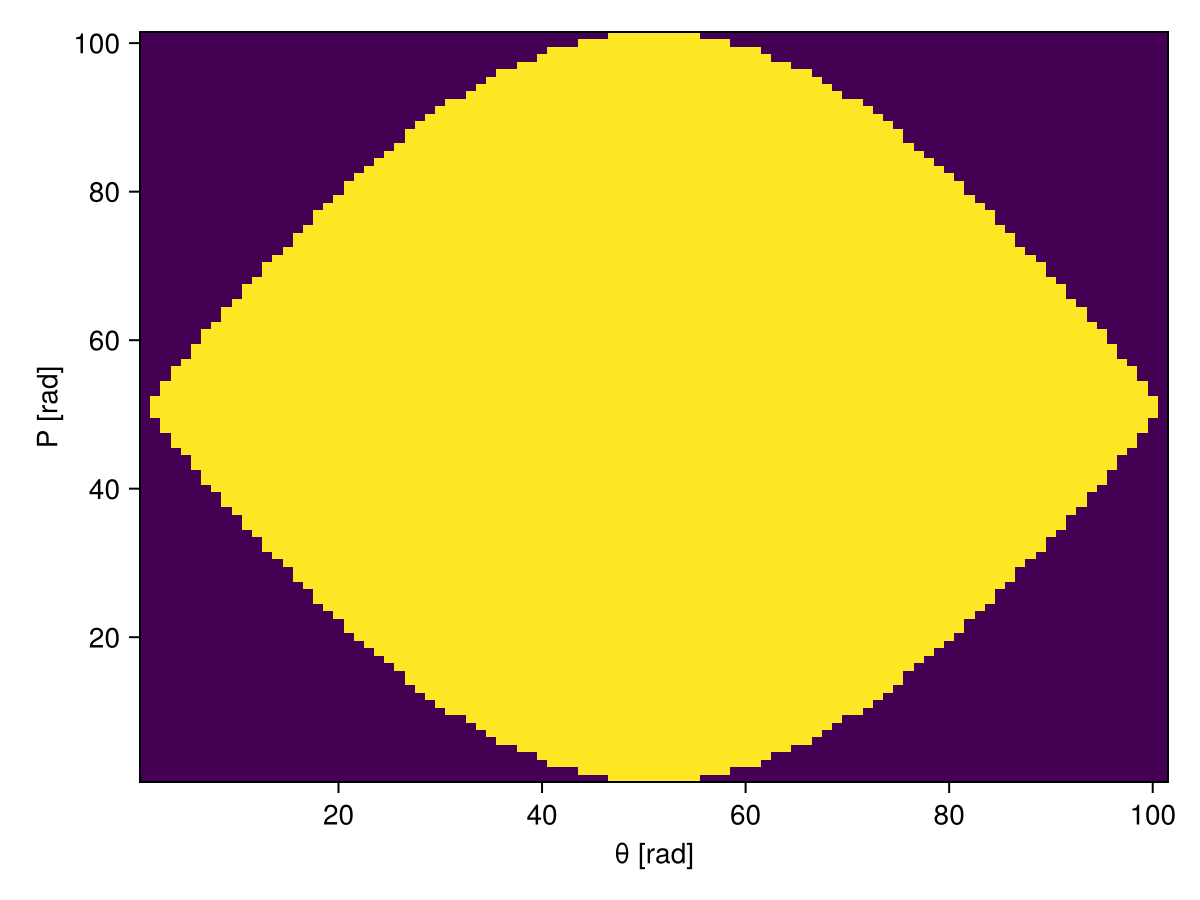

In [6]:
heatmap(grid.mask',
    axis=(xlabel="θ [rad]", ylabel="P [rad]"),
    colormap=:viridis,
    colorrange=(0, 1),
)


In [7]:
# ## Precompute the tomographic response matrix
#
# If `w` contains the initial cell masses, the complete predicted cascade is
#
#     y_hat = A*w
#
# followed only by a reshape. Exact elliptic transport is therefore evaluated
# once rather than at every optimization step.

response = build_response_matrix(
    grid,
    turns,
    machine,
    time_bin_centers_s;
    sigma=soft_sigma_s,
)

response_megabytes = Base.summarysize(response.matrix) / 1024^2

@printf(
    "response dimensions   = %d x %d\n",
    size(response.matrix, 1),
    size(response.matrix, 2),
)
@printf("response memory       = %.1f MiB\n", response_megabytes)

# Every response column deposits unit charge at every turn.
response_tensor = reshape(
    response.matrix,
    length(turns),
    n_time_bins,
    length(grid),
)
response_charge_error = maximum(abs.(
    sum(response_tensor; dims=2) .- 1,
))
@printf("response charge error = %.3e\n", response_charge_error)

response dimensions   = 7575 x 6487
response memory       = 374.9 MiB
response charge error = 7.772e-16


In [8]:
"""
    log_spiral_1arm_multiturn_2d(x, y; kwargs...)

Logarithm of an unnormalized single-arm, multi-turn logarithmic
spiral density.

`x` and `y` may be scalars or arrays with the same shape.
"""
function log_spiral_1arm_multiturn_2d(
    x,
    y;
    x0=0.0,
    y0=0.0,
    r0=1.0,
    spiral_growth=0.08,
    theta0=0.0,
    sigma_r=0.2,
    R_env=1.0,
    env_power=1.5,
    n_turns=20,
)
    sigma_r > 0 || throw(ArgumentError("sigma_r must be positive"))
    R_env > 0 || throw(ArgumentError("R_env must be positive"))
    n_turns >= 0 || throw(ArgumentError("n_turns must be nonnegative"))

    # Coordinates relative to the spiral center
    X = x .- x0
    Y = y .- y0

    radius = sqrt.(X.^2 .+ Y.^2)
    polar_angle = atan.(Y, X)

    # Each column corresponds to one 2π-wrapped spiral branch.
    branch_logdensities = hcat([
        begin
            branch_angle = polar_angle .+ 2π * branch_index

            arm_radius = r0 .* exp.(
                spiral_growth .* (branch_angle .- theta0)
            )

            -0.5 .* ((radius .- arm_radius) ./ sigma_r).^2
        end
        for branch_index in -n_turns:n_turns
    ]...)

    # Stable log-sum-exp over the wrapped branches
    maximum_branch = maximum(branch_logdensities; dims=2)

    log_spiral = vec(
        maximum_branch .+
        log.(
            sum(
                exp.(branch_logdensities .- maximum_branch);
                dims=2,
            )
        )
    )

    # Radial confining envelope
    log_envelope = -0.5 .* (radius ./ R_env).^env_power

    return log_spiral .+ log_envelope
end

log_spiral_1arm_multiturn_2d

In [9]:
# Active phase-space grid centers inside the separatrix
theta_nodes = grid.theta_nodes
P_nodes = grid.P_nodes

# Scale the two axes to comparable ranges.
theta_scale = π
P_scale = 2.0

x_nodes = theta_nodes ./ theta_scale
y_nodes = P_nodes ./ P_scale

target_log_weights = log_spiral_1arm_multiturn_2d(
    x_nodes,
    y_nodes;
    x0=0.1,
    y0=0.1,
    r0=0.1,
    spiral_growth=.06,
    theta0=1,
    sigma_r=0.03,
    R_env=1,
    env_power=1.4,
    n_turns=7,
)

# Stable conversion from log-density to phase-space cell masses
maximum_log_weight = maximum(target_log_weights)

target_weights_unnormalized = exp.(
    target_log_weights .- maximum_log_weight
)

target_weights = target_weights_unnormalized ./
                 sum(target_weights_unnormalized)

# Generate the synthetic RWCM cascade
target_profiles = profiles_from_response(
    response,
    target_weights,
)

@printf("target charge         = %.12f\n", sum(target_weights))
@printf(
    "target profile error = %.3e\n",
    maximum(abs.(sum(target_profiles; dims=2) .- 1)),
)

target charge         = 1.000000000000
target profile error = 1.221e-15


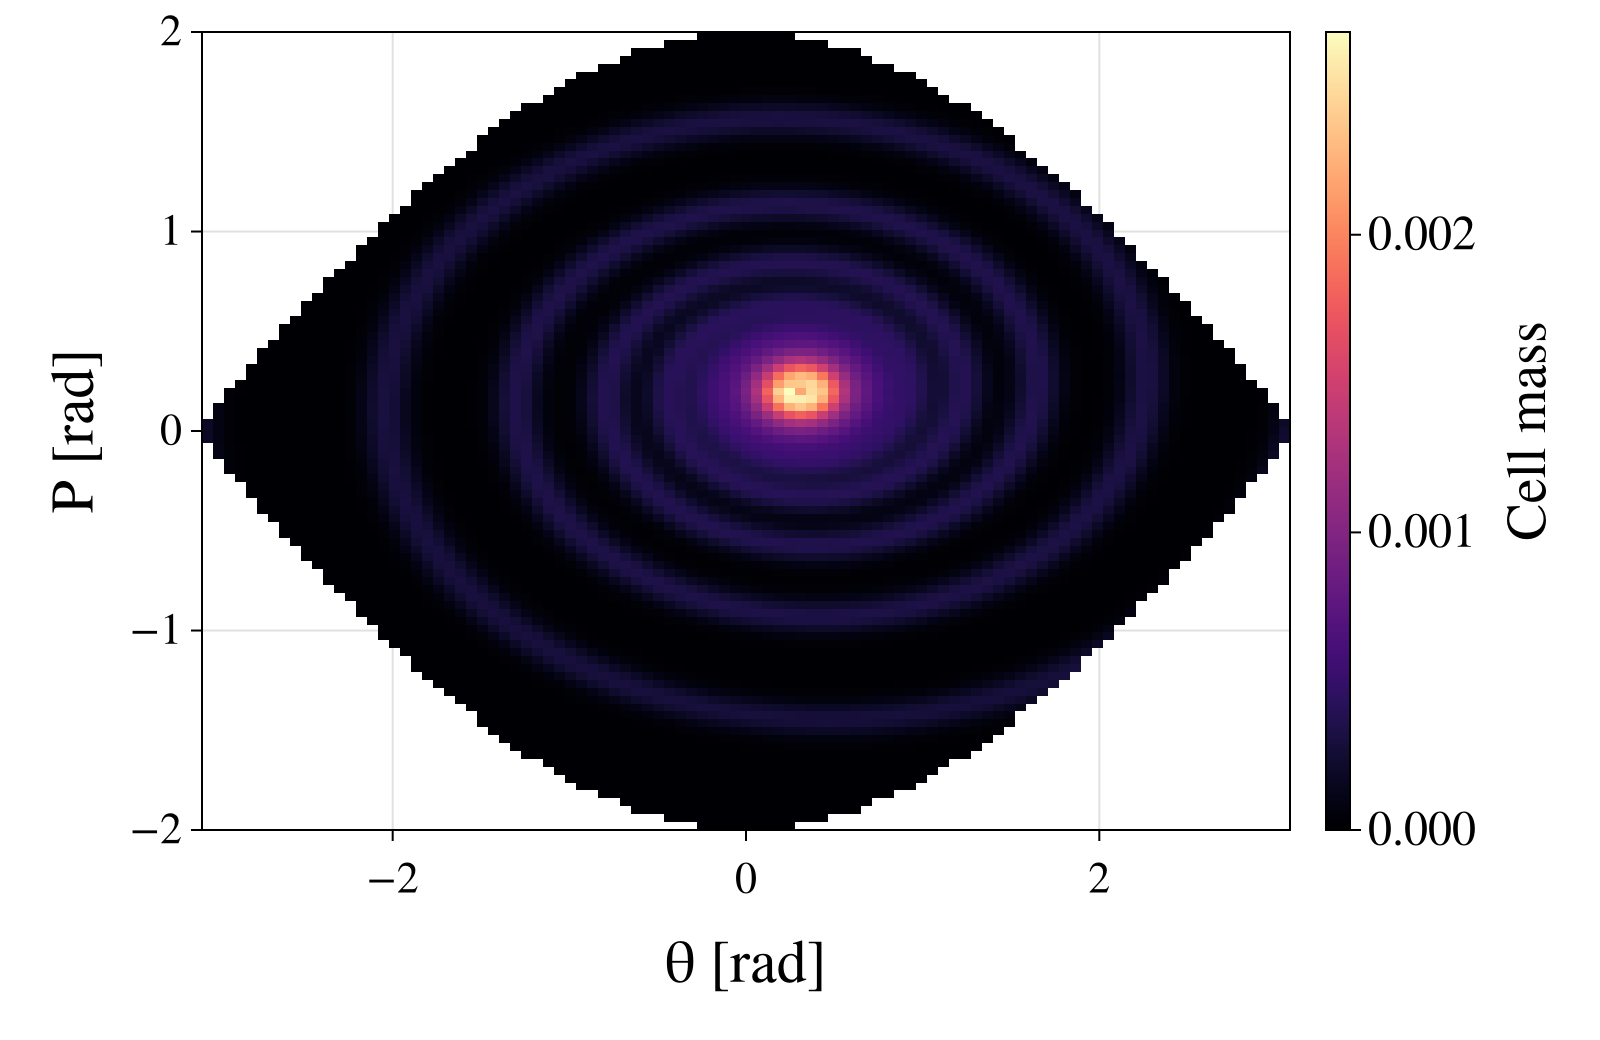

CairoMakie.Screen{IMAGE}


In [10]:
# Plot the target distribution and profiles
weight_figure = Figure(size=(800, 520))
weight_axis = Axis(
    weight_figure[1,1];
    xlabel="θ [rad]",
    ylabel="P [rad]",
    xlabelfont = "StixGeneral",
    ylabelfont = "StixGeneral",

    xlabelsize = 30,
    ylabelsize = 30,


    xticklabelfont = "StixGeneral",
    yticklabelfont = "StixGeneral",
    xticklabelsize = 22,
    yticklabelsize = 22,
)

heat=heatmap!(
    weight_axis,
    grid.theta_nodes,
    grid.P_nodes,
    target_weights;
    colormap=:magma,
    colorrange=(0, maximum(target_weights)),
)

# Change weight_axis to weight_figure[1, 2]
Colorbar(
    weight_figure[1, 2],
    heat; 
    label = "Cell mass",
    labelsize = 28,
    ticklabelsize = 24,
    ticklabelfont = "StixGeneral",
    labelfont = "StixGeneral",
)


display(weight_figure)

In [11]:
spiral_image = fill(
    NaN,
    size(grid.index_map),
)

for cartesian_index in CartesianIndices(grid.index_map)
    active_index = grid.index_map[cartesian_index]

    if active_index > 0
        spiral_image[cartesian_index] =
            target_weights[active_index]
    end
end

# Logarithmic scaling of the spiral image for visualization

maximum_mass = maximum(target_weights)
relative_floor = 1e-4

spiral_log_image = map(spiral_image) do mass
    if !isfinite(mass)
        NaN
    else
        log10(max(mass / maximum_mass, relative_floor))
    end
end

101×101 Matrix{Float64}:
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  …  NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  …  NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  …  NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN

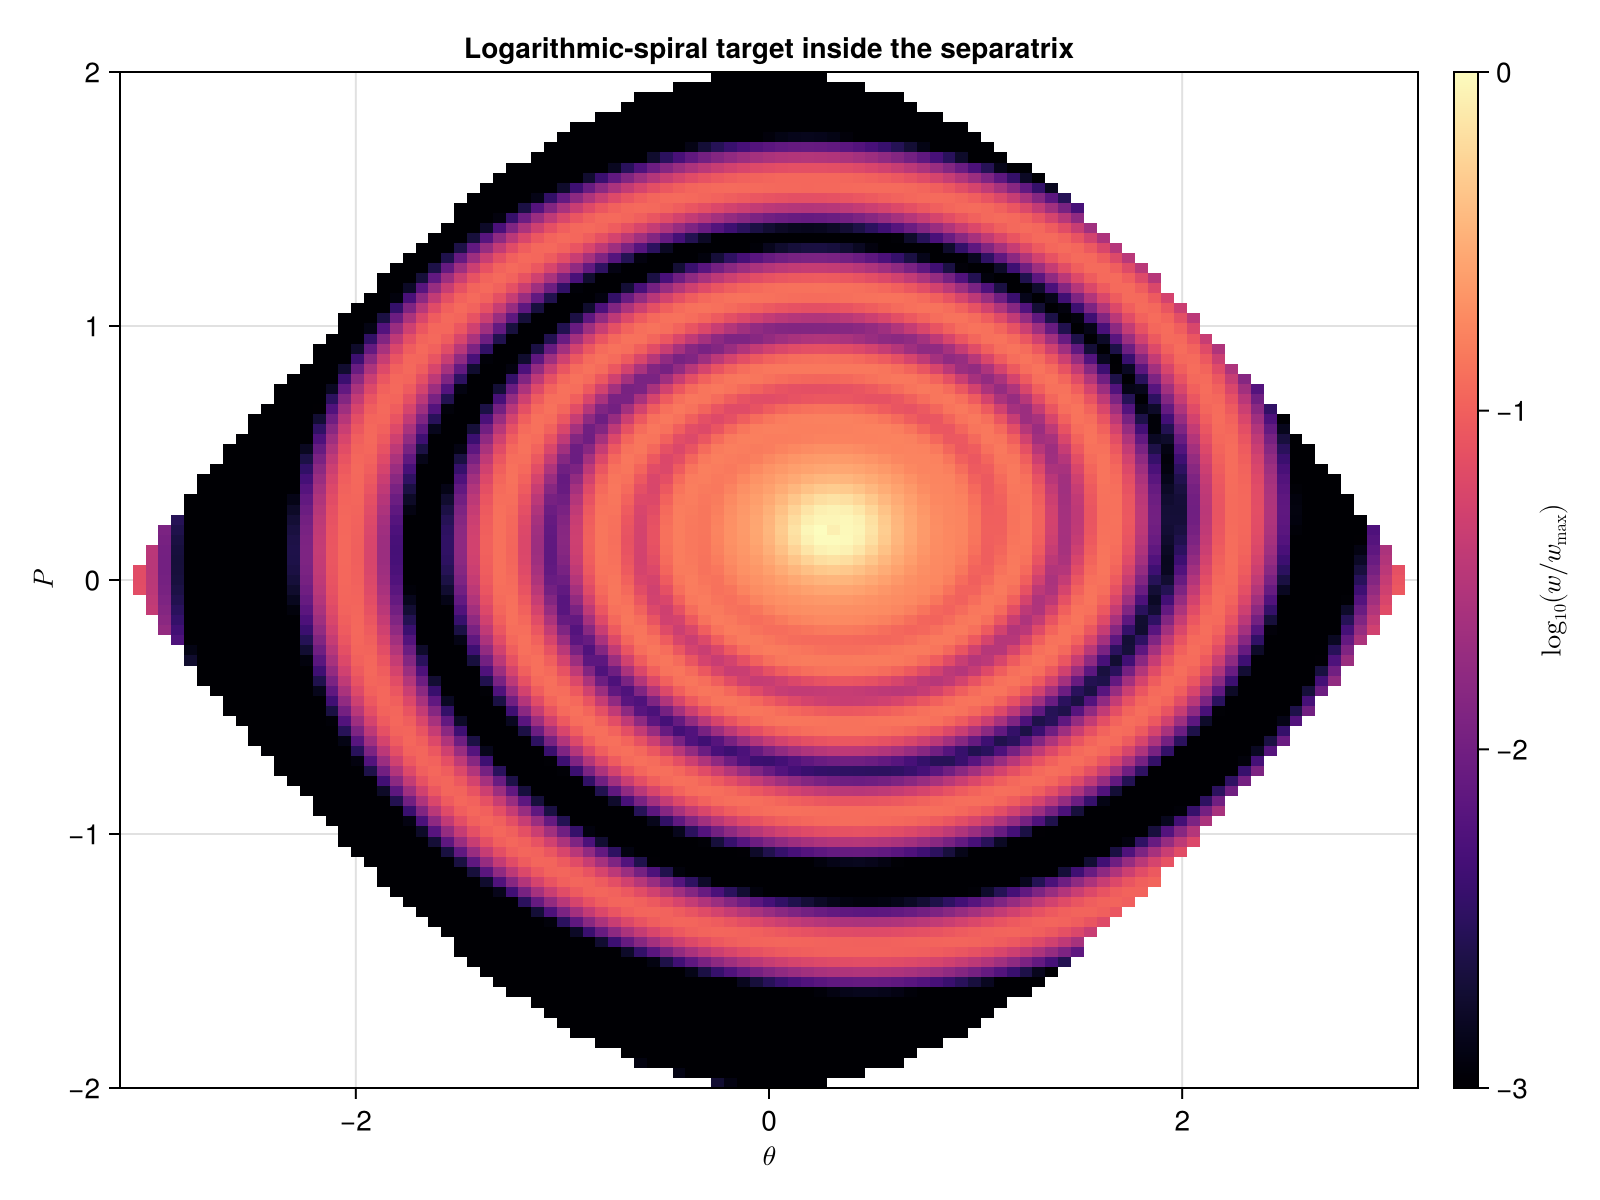

CairoMakie.Screen{IMAGE}


In [12]:
spiral_figure = Figure(size=(800, 600))

spiral_axis = Axis(
    spiral_figure[1, 1];
    xlabel=L"\theta",
    ylabel=L"P",
    title="Logarithmic-spiral target inside the separatrix",
)

spiral_heatmap = heatmap!(
    spiral_axis,
    grid.theta_axis,
    grid.P_axis,
    permutedims(spiral_log_image);
    colormap=:magma,
    colorrange=(-3, 0),
)

Colorbar(
    spiral_figure[1, 2],
    spiral_heatmap;
    label=L"\log_{10}(w/w_{\max})",
)

display(spiral_figure)

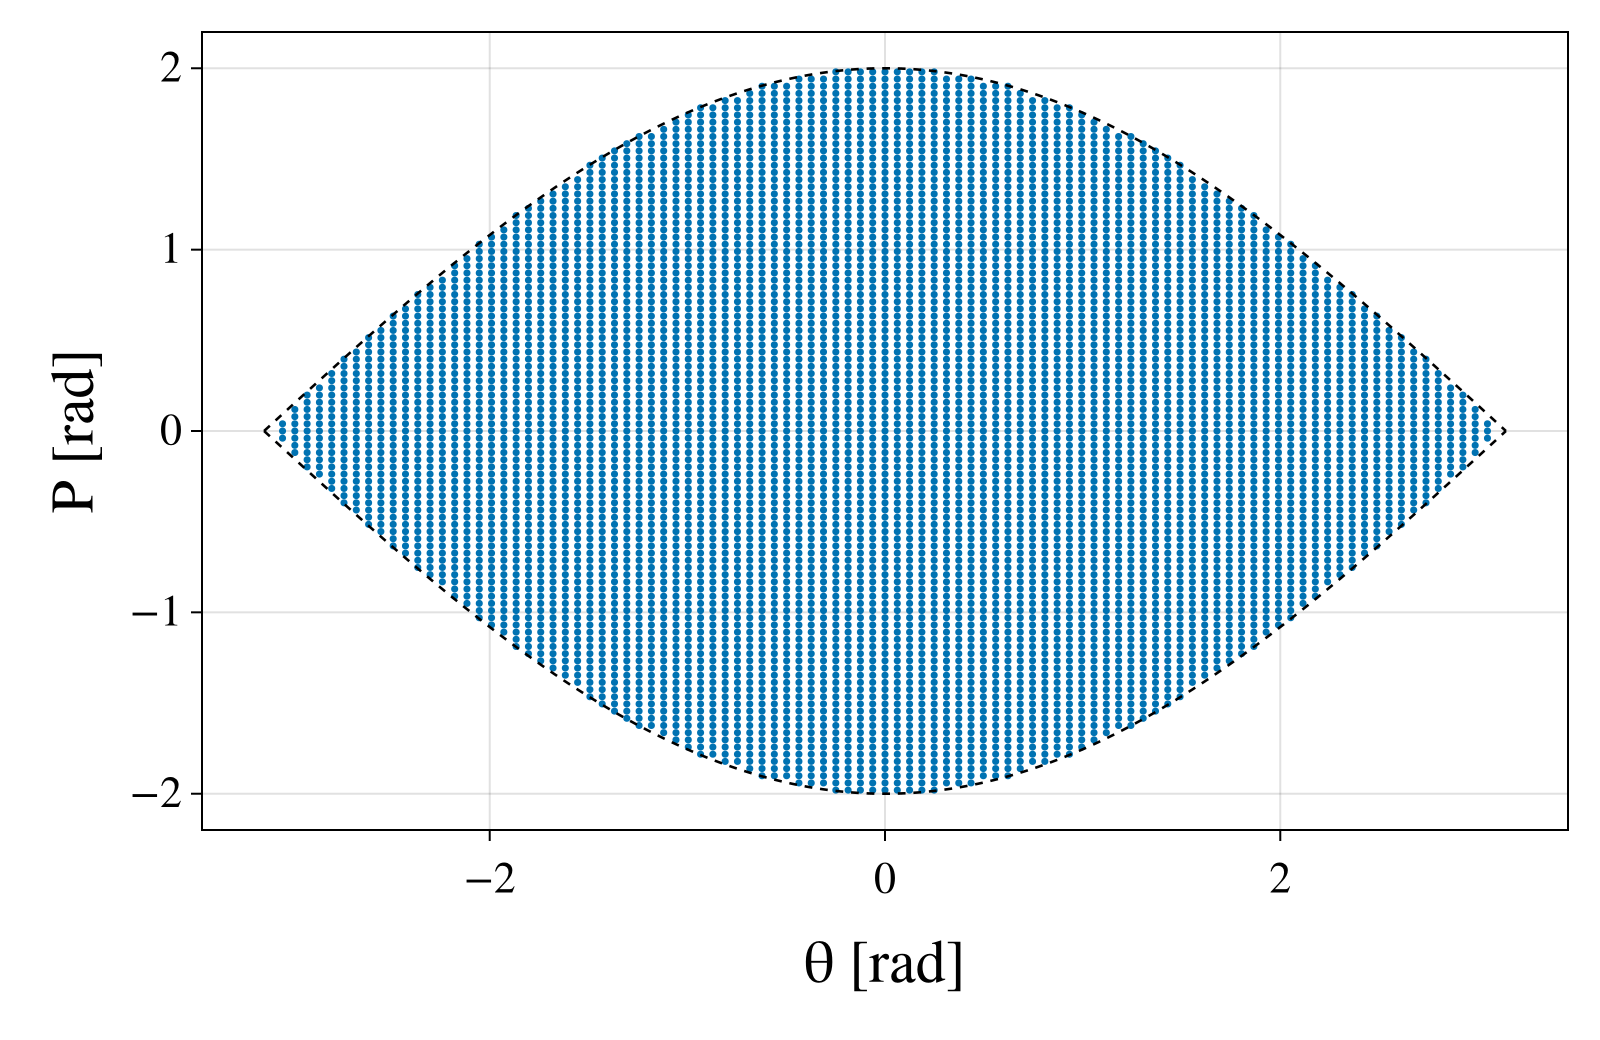

CairoMakie.Screen{IMAGE}


In [13]:
grid_figure = Figure(size=(800, 520))
grid_axis = Axis(
    grid_figure[1,1];
    xlabel="θ [rad]",
    ylabel="P [rad]",
    xlabelfont = "StixGeneral",
    ylabelfont = "StixGeneral",

    xlabelsize = 30,
    ylabelsize = 30,


    xticklabelfont = "StixGeneral",
    yticklabelfont = "StixGeneral",
    xticklabelsize = 22,
    yticklabelsize = 22,
)

scatter!(
    grid_axis,
    grid.theta_nodes,
    grid.P_nodes,
    markersize=5,
)

lines!(
    grid_axis,
    theta_separatrix,
    P_separatrix;
    color=:black,
    linestyle=:dash,
    linewidth=1.3,
)

lines!(
    grid_axis,
    theta_separatrix,
    -P_separatrix;
    color=:black,
    linestyle=:dash,
    linewidth=1.3,
)
display(grid_figure)

In [14]:
# ## Reconstruct the unknown cell masses
#
# The initial logits are zero, corresponding to a uniform density over active
# cells. The fit uses only the training turns. The regularizers are deliberately
# weak so that the profile data dominate this first demonstration.

# Initialize the reconstruction with uniform weights
initial_logits = zeros(length(grid))
initial_profiles = profiles_from_response(
    response,
    grid_weights_from_logits(initial_logits);
    normalize=false,
)
initial_training_mse = profile_mse(
    initial_profiles,
    target_profiles;
    turn_indices=training_turn_indices,
)

# Reconstruct the grid weights and profiles
result = reconstruct_grid(
    response,
    target_profiles;
    iterations=2000,
    learning_rate=0.08,
    initial_logits=initial_logits,
    train_turn_indices=training_turn_indices,
    lambda_tv=1e-2,
    lambda_entropy=1e-6,
)

reconstructed_weights = result.weights
reconstructed_profiles = result.profiles

final_training_mse = profile_mse(
    reconstructed_profiles,
    target_profiles;
    turn_indices=training_turn_indices,
)
validation_mse = profile_mse(
    reconstructed_profiles,
    target_profiles;
    turn_indices=validation_turn_indices,
)
phase_space_l1 = sum(abs.(reconstructed_weights .- target_weights))

@printf("initial training MSE  = %.6e\n", initial_training_mse)
@printf("final training MSE    = %.6e\n", final_training_mse)
@printf("held-out-turn MSE     = %.6e\n", validation_mse)
@printf("phase-space L1 error  = %.6e\n", phase_space_l1)
@printf("reconstructed charge = %.12f\n", sum(reconstructed_weights))

initial training MSE  = 9.776078e-05
final training MSE    = 9.591026e-08
held-out-turn MSE     = 1.127847e-07
phase-space L1 error  = 1.761976e-01
reconstructed charge = 1.000000000000


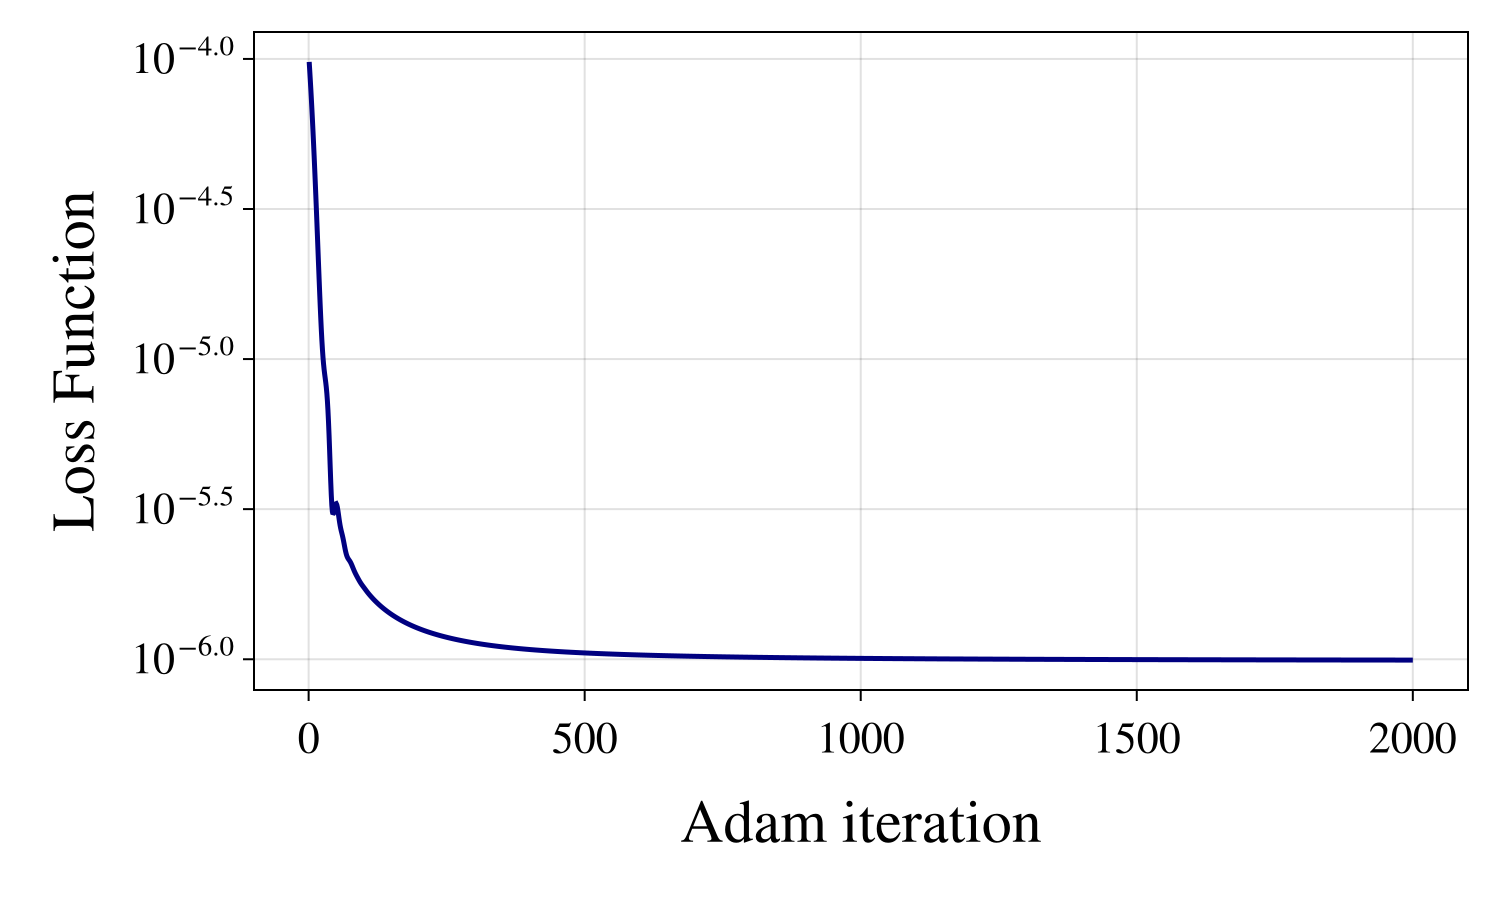

CairoMakie.Screen{IMAGE}


In [15]:
loss_figure = Figure(size=(750, 450))
loss_axis = Axis(
    loss_figure[1, 1];
    xlabel="Adam iteration",
    ylabel="Loss Function",
    yscale=log10,
    xlabelfont = "StixGeneral",
    ylabelfont = "StixGeneral",
    xlabelsize = 30,
    ylabelsize = 30,
    xticklabelfont = "StixGeneral",
    yticklabelfont = "StixGeneral",
    xticklabelsize = 22,
    yticklabelsize = 22,
)
lines!(
    loss_axis,
    eachindex(result.loss_history),
    max.(result.loss_history, eps(Float64));
    color=:navy,
    linewidth=2.5,
)

display(loss_figure)

In [16]:
# ## Initial phase-space reconstruction in physical coordinates

function physical_grid_plot_data(grid, weights, machine)
    weight_matrix = grid_weight_matrix(grid, weights)
    delta_t_axis_ns = delta_t_from_theta(grid.theta_axis, machine) .* 1e9
    delta_E_axis_MeV = delta_energy_from_P(grid.P_axis, machine) .* 1e-6

    # eta0 < 0 makes Delta E decrease with normalized P. Sort the physical
    # energy axis before plotting and reorder the corresponding matrix rows.
    energy_order = sortperm(delta_E_axis_MeV)
    plot_matrix = permutedims(weight_matrix[energy_order, :])
    return delta_t_axis_ns, delta_E_axis_MeV[energy_order], plot_matrix
end

target_dt_ns, target_dE_MeV, target_matrix = physical_grid_plot_data(
    grid,
    target_weights,
    machine,
)
reconstructed_dt_ns, reconstructed_dE_MeV, reconstructed_matrix =
    physical_grid_plot_data(grid, reconstructed_weights, machine)
difference_matrix = reconstructed_matrix .- target_matrix

theta_separatrix = range(-pi, pi; length=1000)
P_separatrix = 2 .* cos.(theta_separatrix ./ 2)
delta_t_separatrix_ns = delta_t_from_theta(theta_separatrix, machine) .* 1e9
delta_E_separatrix_upper_MeV = delta_energy_from_P(
    P_separatrix,
    machine,
) .* 1e-6
delta_E_separatrix_lower_MeV = delta_energy_from_P(
    -P_separatrix,
    machine,
) .* 1e-6

1000-element Vector{Float64}:
 5.711584747872435e-16
 0.029333199623525544
 0.058666109160329646
 0.08799843852656078
 0.11732989764410437
 0.14666019644345202
 0.17598904486657024
 0.20531615286977076
 0.2346412304265709
 0.2639639875305738
 0.2932841341983287
 0.3226013804722
 0.3519154364232353
 ⋮
 0.3226013804722
 0.2932841341983287
 0.2639639875305738
 0.2346412304265709
 0.2053161528697687
 0.17598904486657024
 0.14666019644345202
 0.11732989764410437
 0.08799843852656078
 0.058666109160329646
 0.029333199623525544
 5.711584747872435e-16

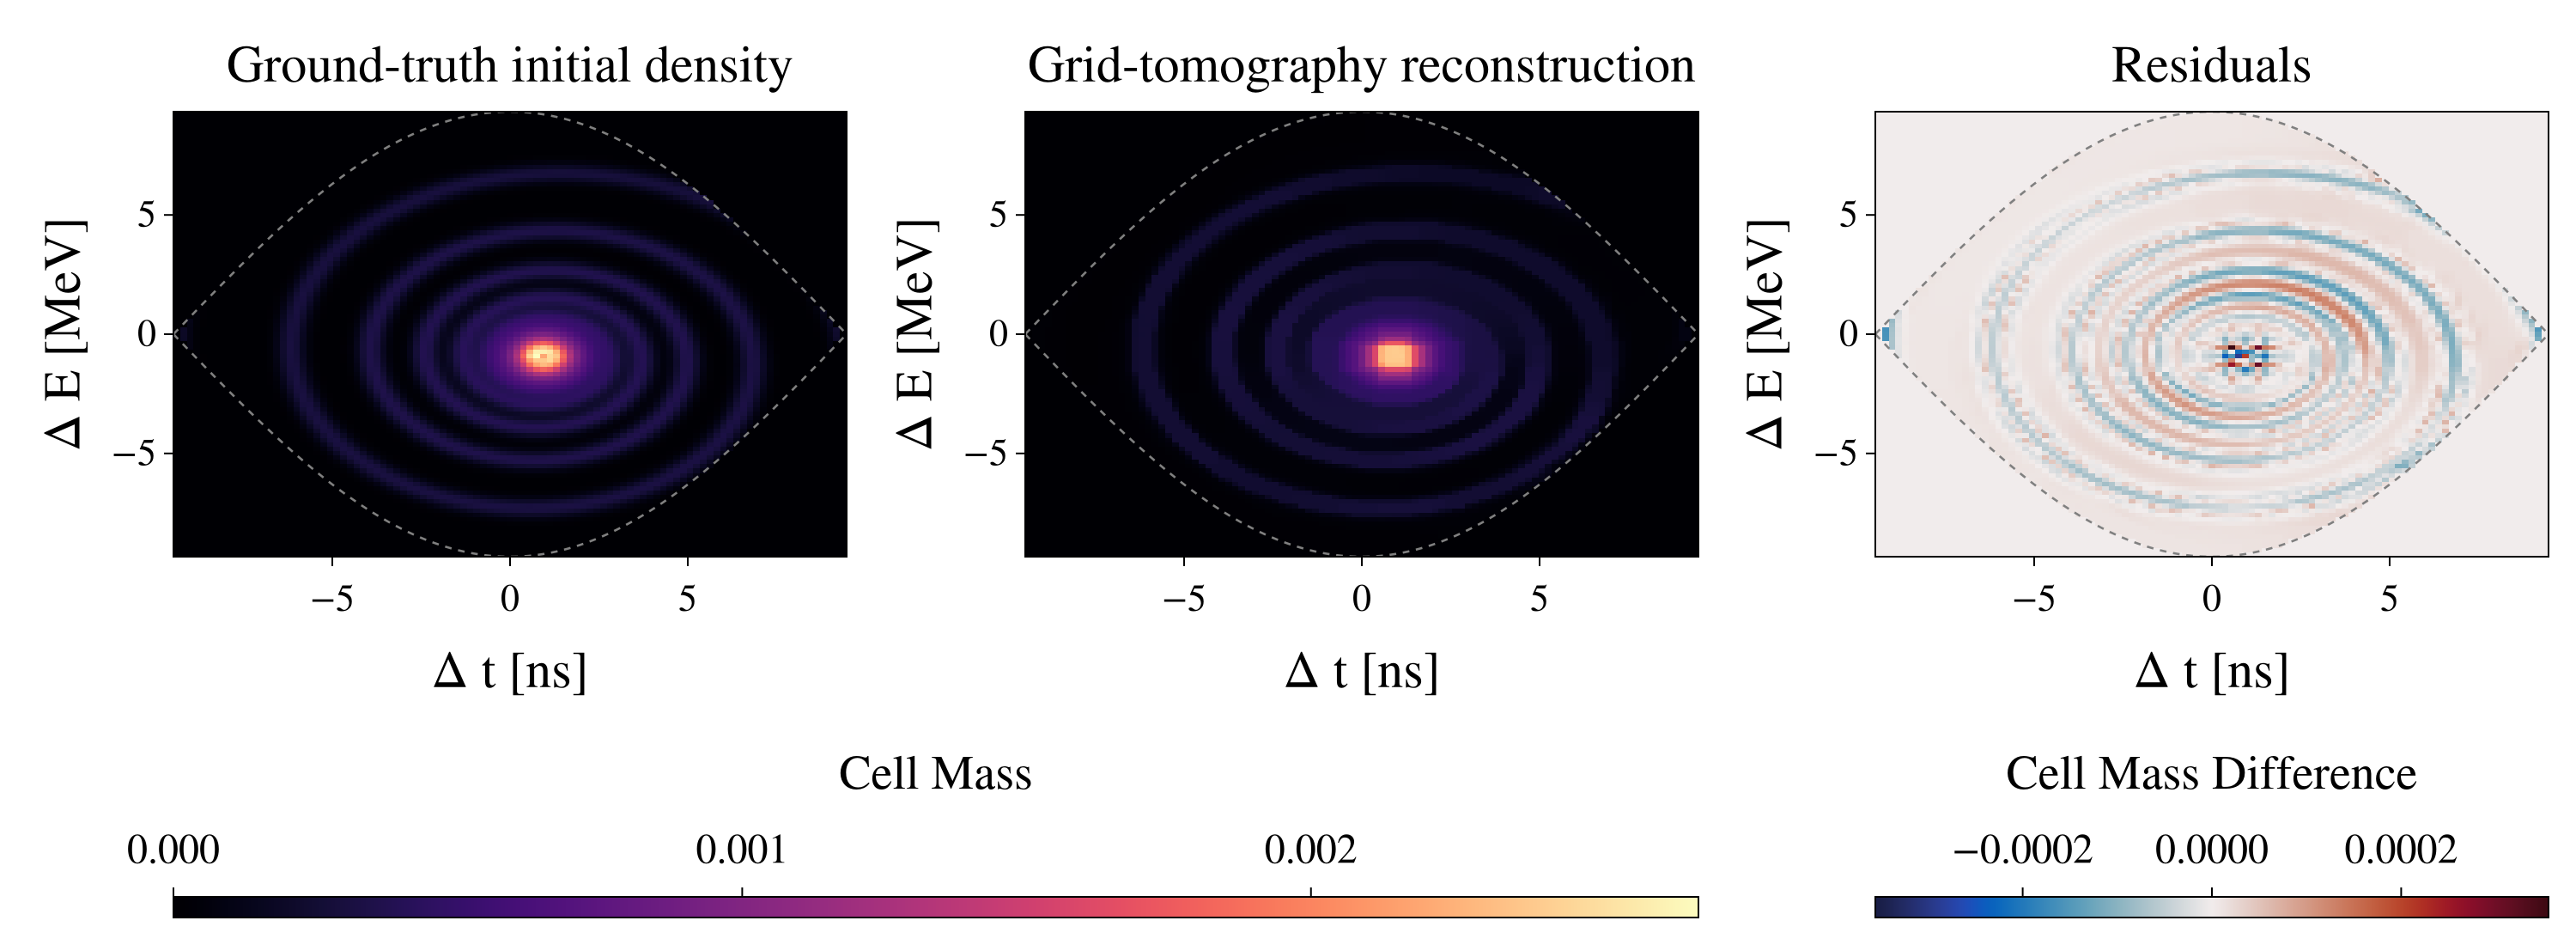

CairoMakie.Screen{IMAGE}


In [17]:

phase_figure = Figure(size=(1500, 550))
common_colorrange = (
    0.0,
    max(maximum(target_matrix), maximum(reconstructed_matrix)),
)
difference_limit = max(maximum(abs.(difference_matrix)), eps(Float64))

axis_target = Axis(
    phase_figure[1, 1];
    xlabel="Δ t [ns]",
    ylabel="Δ E [MeV]",
    title="Ground-truth initial density",
    titlefont = "StixGeneral",
    titlesize = 30,
    xlabelfont = "StixGeneral",
    ylabelfont = "StixGeneral",
    xlabelsize = 30,
    ylabelsize = 30,
    xticklabelfont = "StixGeneral",
    yticklabelfont = "StixGeneral",
    xticklabelsize = 22,
    yticklabelsize = 22,
)
target_heatmap = heatmap!(
    axis_target,
    target_dt_ns,
    target_dE_MeV,
    target_matrix;
    colormap=:magma,
    colorrange=common_colorrange,
)

axis_reconstruction = Axis(
    phase_figure[1, 2];
    xlabel="Δ t [ns]",
    ylabel="Δ E [MeV]",
    title="Grid-tomography reconstruction",
    titlefont = "StixGeneral",
    titlesize = 30,
    xlabelfont = "StixGeneral",
    ylabelfont = "StixGeneral",
    xlabelsize = 30,
    ylabelsize = 30,
    xticklabelfont = "StixGeneral",
    yticklabelfont = "StixGeneral",
    xticklabelsize = 22,
    yticklabelsize = 22,
)

heatmap!(
    axis_reconstruction,
    reconstructed_dt_ns,
    reconstructed_dE_MeV,
    reconstructed_matrix;
    colormap=:magma,
    colorrange=common_colorrange,
)

axis_difference = Axis(
    phase_figure[1, 3];
    xlabel="Δ t [ns]",
    ylabel="Δ E [MeV]",
    title="Residuals",
    titlefont = "StixGeneral",
    titlesize = 30,
    xlabelfont = "StixGeneral",
    ylabelfont = "StixGeneral",
    xlabelsize = 30,
    ylabelsize = 30,
    xticklabelfont = "StixGeneral",
    yticklabelfont = "StixGeneral",
    xticklabelsize = 22,
    yticklabelsize = 22,
)
difference_heatmap = heatmap!(
    axis_difference,
    target_dt_ns,
    target_dE_MeV,
    difference_matrix;
    colormap=:balance,
    colorrange=(-difference_limit, difference_limit),
)

for axis in (axis_target, axis_reconstruction, axis_difference)
    lines!(
        axis,
        delta_t_separatrix_ns,
        delta_E_separatrix_upper_MeV;
        color=:gray,
        linestyle=:dash,
        linewidth=1.3,
    )
    lines!(
        axis,
        delta_t_separatrix_ns,
        delta_E_separatrix_lower_MeV;
        color=:gray,
        linestyle=:dash,
        linewidth=1.3,
    )
end

Colorbar(phase_figure[2, 1:2], target_heatmap; vertical=false, label="Cell Mass",
    labelsize = 28,
    ticklabelsize = 24,
    ticklabelfont = "StixGeneral",
    labelfont = "StixGeneral",
)
Colorbar(
    phase_figure[2, 3],
    difference_heatmap;
    vertical=false,
    label="Cell Mass Difference",
    labelsize = 28,
    ticklabelsize = 24,
    ticklabelfont = "StixGeneral",
    labelfont = "StixGeneral",
)

display(phase_figure)

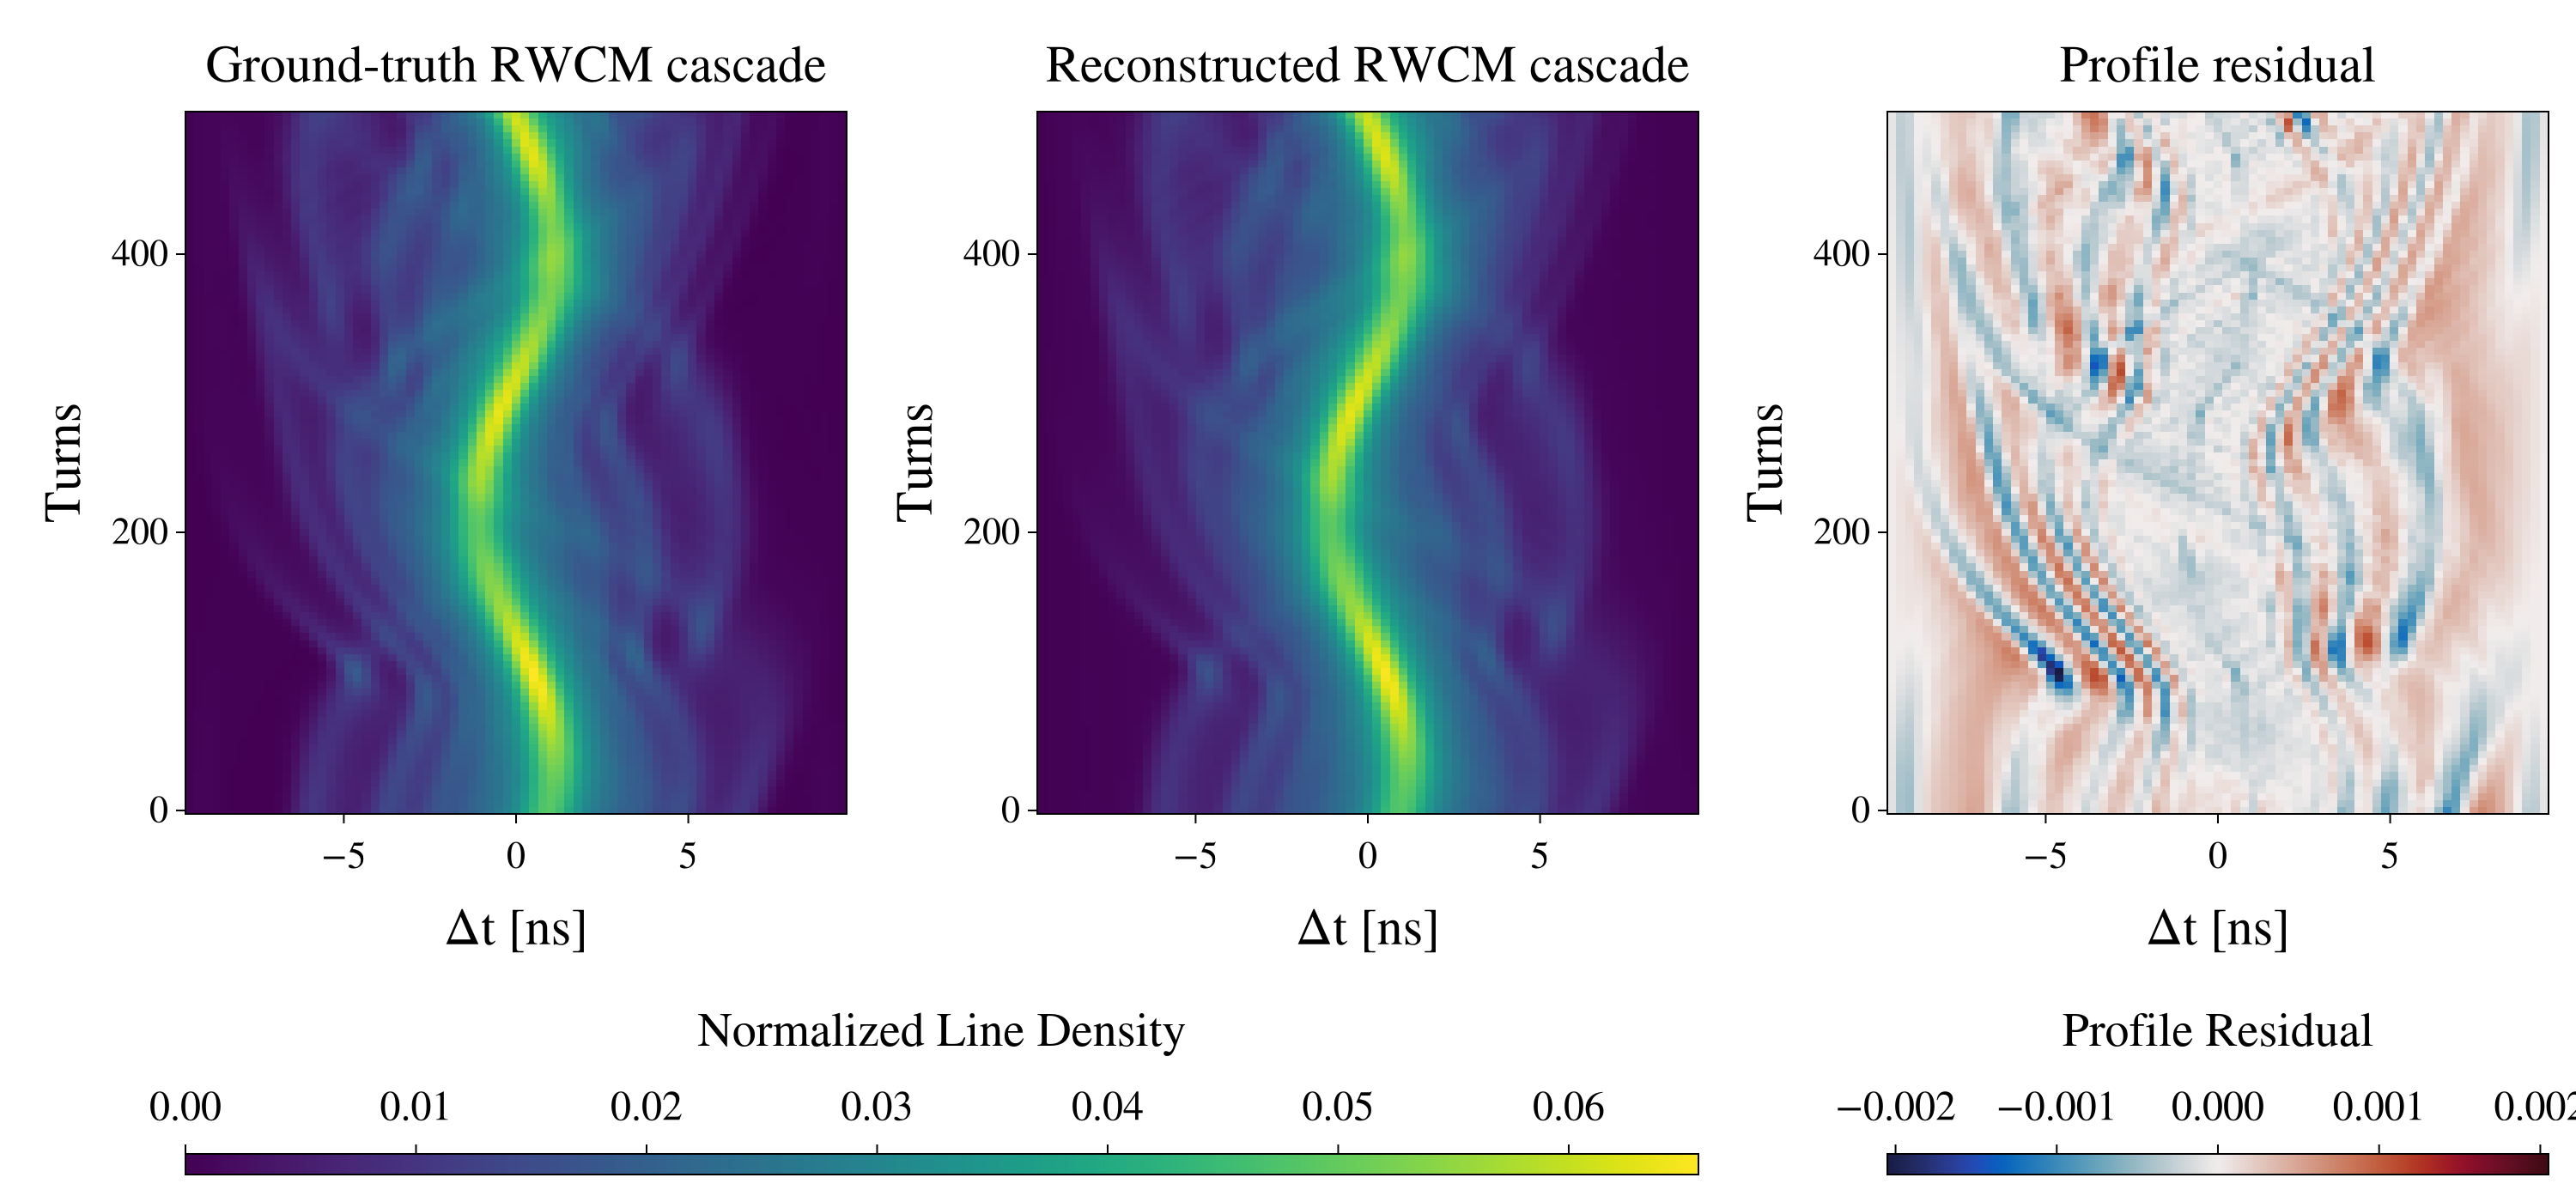

CairoMakie.Screen{IMAGE}


In [18]:
profile_residual = reconstructed_profiles .- target_profiles
profile_limit = max(maximum(target_profiles), maximum(reconstructed_profiles))
residual_limit = max(maximum(abs.(profile_residual)), eps(Float64))

cascade_figure = Figure(size=(1500, 700)) # Adjusted height slightly to 550 to match your reference layout math

axis_target_cascade = Axis(
    cascade_figure[1, 1];
    xlabel="Δt [ns]",
    ylabel="Turns",
    title="Ground-truth RWCM cascade",
    titlefont = "StixGeneral",
    titlesize = 30,
    xlabelfont = "StixGeneral",
    ylabelfont = "StixGeneral",
    xlabelsize = 30,
    ylabelsize = 30,
    xticklabelfont = "StixGeneral",
    yticklabelfont = "StixGeneral",
    xticklabelsize = 22,
    yticklabelsize = 22,
)
target_cascade_heatmap = heatmap!(
    axis_target_cascade,
    time_bin_centers_s .* 1e9,
    turns,
    permutedims(target_profiles);
    colormap=:viridis,
    colorrange=(0, profile_limit),
)

axis_reconstructed_cascade = Axis(
    cascade_figure[1, 2];
    xlabel="Δt [ns]",
    ylabel="Turns",
    title="Reconstructed RWCM cascade",
    titlefont = "StixGeneral",
    titlesize = 30,
    xlabelfont = "StixGeneral",
    ylabelfont = "StixGeneral",
    xlabelsize = 30,
    ylabelsize = 30,
    xticklabelfont = "StixGeneral",
    yticklabelfont = "StixGeneral",
    xticklabelsize = 22,
    yticklabelsize = 22,
)
heatmap!(
    axis_reconstructed_cascade,
    time_bin_centers_s .* 1e9,
    turns,
    permutedims(reconstructed_profiles);
    colormap=:viridis,
    colorrange=(0, profile_limit),
)

axis_residual_cascade = Axis(
    cascade_figure[1, 3];
    xlabel="Δt [ns]",
    ylabel="Turns",
    title="Profile residual",
    titlefont = "StixGeneral",
    titlesize = 30,
    xlabelfont = "StixGeneral",
    ylabelfont = "StixGeneral",
    xlabelsize = 30,
    ylabelsize = 30,
    xticklabelfont = "StixGeneral",
    yticklabelfont = "StixGeneral",
    xticklabelsize = 22,
    yticklabelsize = 22,
)
residual_heatmap = heatmap!(
    axis_residual_cascade,
    time_bin_centers_s .* 1e9,
    turns,
    permutedims(profile_residual);
    colormap=:balance,
    colorrange=(-residual_limit, residual_limit),
)

Colorbar(
    cascade_figure[2, 1:2],
    target_cascade_heatmap;
    vertical=false,
    label="Normalized Line Density",
    labelsize = 28,
    ticklabelsize = 24,
    ticklabelfont = "StixGeneral",
    labelfont = "StixGeneral",
)

Colorbar(
    cascade_figure[2, 3],
    residual_heatmap;
    vertical=false,
    label="Profile Residual",
    labelsize = 28,
    ticklabelsize = 24,
    ticklabelfont = "StixGeneral",
    labelfont = "StixGeneral",
    
    # Example: Manually setting ticks every 0.1 units from -0.5 to 0.5
    ticks = -0.005:0.001:0.005 
)


display(cascade_figure)


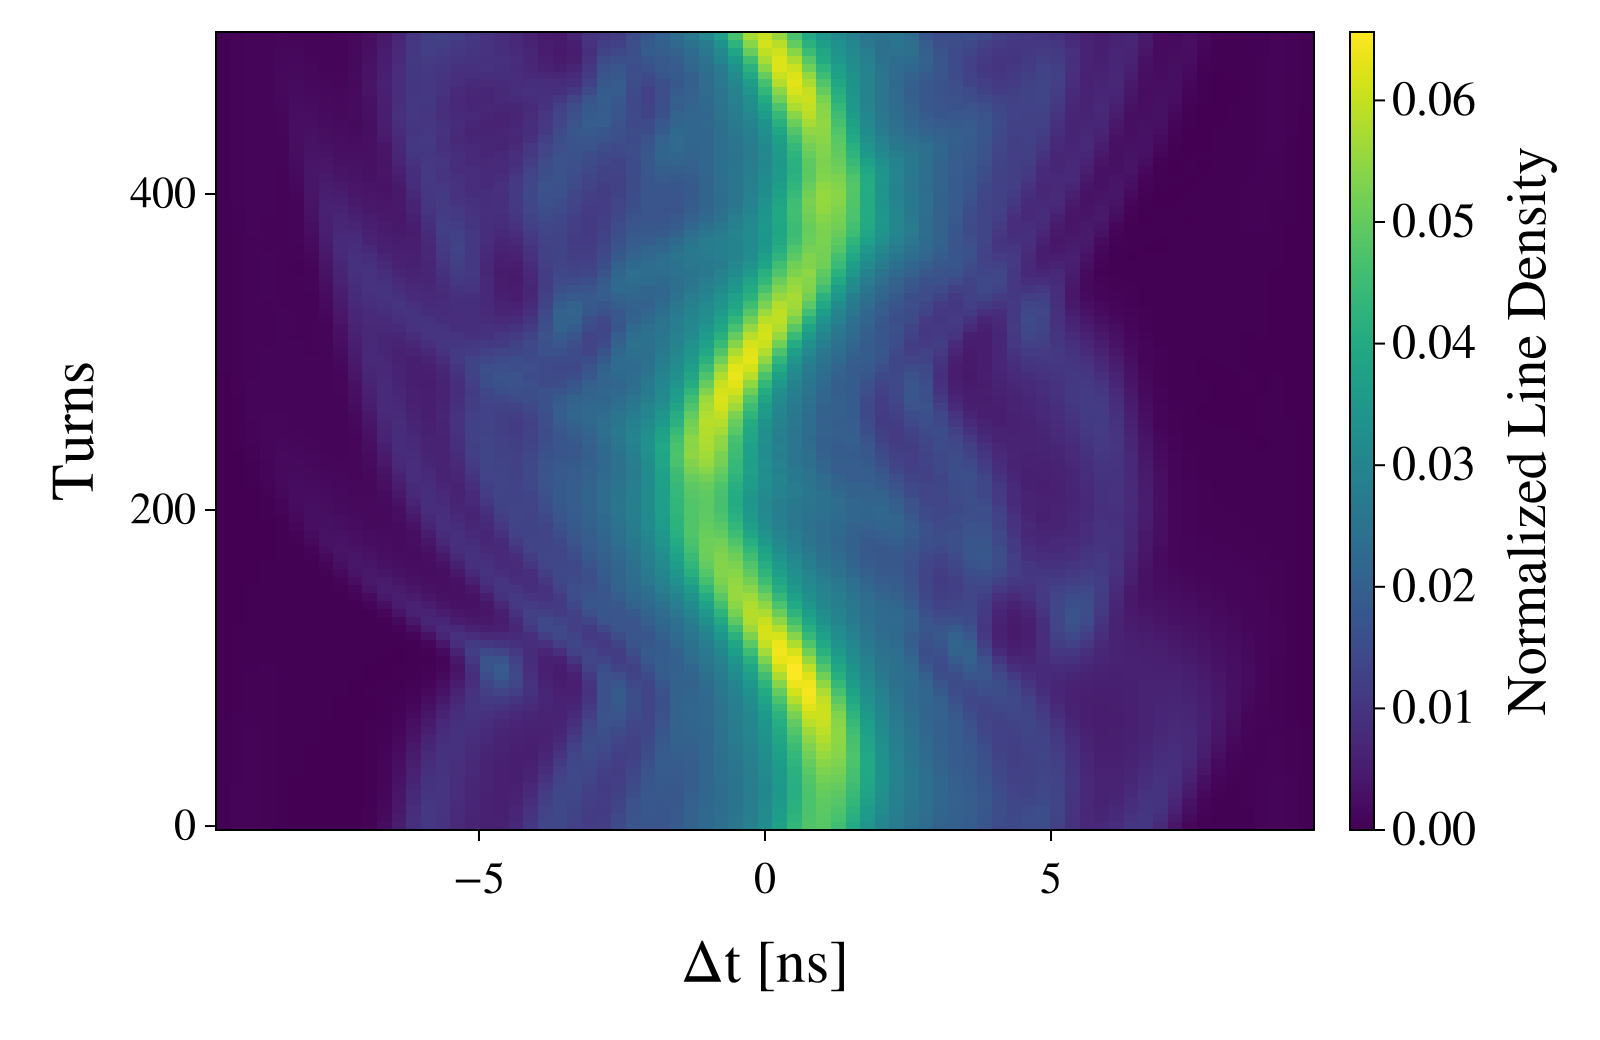

CairoMakie.Screen{IMAGE}


In [19]:
rwcm_figure = Figure(size=(800, 520))

rwcm_axis = Axis(
    rwcm_figure[1, 1]; # Keeps layout tracking matching and intact
    xlabel="Δt [ns]",
    ylabel="Turns",
    xlabelfont="StixGeneral",
    ylabelfont="StixGeneral",
    xticklabelfont="StixGeneral",
    yticklabelfont="StixGeneral",
    xticklabelsize=22,
    yticklabelsize=22,
    xlabelsize=30,
    ylabelsize=30,
)

# Render the heatmap directly to the same grid slot
rwcmheat = heatmap!(
    rwcm_figure[1, 1], 
    time_bin_centers_s .* 1e9,
    turns,
    permutedims(target_profiles);
    colormap=:viridis,
    colorrange=(0, maximum(target_profiles)),
)

# Place the colorbar in the adjacent column slot
Colorbar(
    rwcm_figure[1, 2],
    rwcmheat;
    vertical=true,
    label="Normalized Line Density",
    labelsize=28,
    ticklabelsize=24,
    ticklabelfont="StixGeneral",
    labelfont="StixGeneral",
)

display(rwcm_figure)
